<a href="https://colab.research.google.com/github/vlotran/CMPE188-Homework3/blob/main/Homework3_LLM_Reasoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 0. Imports

In [2]:
# Core
import os, time, re
import numpy as np
import pandas as pd

# ML + metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Section 1. Load the Dataset from Github

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/lkk688/CoderGym/main/Nemotron/train_with_task_type.csv"
df = pd.read_csv(url)

df.shape, df.columns

((9500, 7),
 Index(['id', 'prompt', 'answer', 'task_type', 'task_source', 'task_confidence',
        'task_reason'],
       dtype='object'))

# Section 2. Build the text input (prompt + answer) + basic cleanup

In [4]:
# Combine prompt + answer into one text field
df["text"] = df["prompt"].fillna("") + "\n\n" + df["answer"].fillna("")

# Target label
df["label"] = df["task_type"]

# Keep only what we need for modeling
data = df[["id", "text", "label"]].copy()

data.head()

,id,text,label
0,00066667,"In Alice's Wonderland, a secret bit manipulati...",bit_manipulation
1,000b53cf,"In Alice's Wonderland, a secret bit manipulati...",bit_manipulation
2,00189f6a,"In Alice's Wonderland, secret encryption rules...",cipher_text
3,001b24c4,"In Alice's Wonderland, numbers are secretly co...",roman
4,001c63cb,"In Alice's Wonderland, secret encryption rules...",cipher_text


# Section 3. Check Labels (how many classes + imbalance)

In [5]:
# How many classes?
n_classes = data["label"].nunique()
print("Number of unique labels (task_type):", n_classes)

# Any missing labels?
print("Missing labels:", data["label"].isna().sum())

# Class counts (top and bottom)
label_counts = data["label"].value_counts()
display(label_counts.head(10))
display(label_counts.tail(10))

Number of unique labels (task_type): 6
Missing labels: 0


,count
label,
bit_manipulation,1602
gravity,1597
unit_conversion,1594
cipher_text,1576
roman,1576
symbol_transform,1555


,count
label,
bit_manipulation,1602
gravity,1597
unit_conversion,1594
cipher_text,1576
roman,1576
symbol_transform,1555


# Section 4. Train/Test Split (stratified)

In [6]:
from sklearn.model_selection import train_test_split

X = data["text"].values
y = data["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 7600
Test size : 1900


# Section 5. Pipeline #1: TF‑IDF + Naive Bayes (with train + inference timing)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Build model pipeline
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1,2),     # unigrams + bigrams
        min_df=2               # ignore extremely rare terms
    )),
    ("clf", MultinomialNB())
])

# ---- Train timing ----
t0 = time.perf_counter()
pipe_nb.fit(X_train, y_train)
train_time = time.perf_counter() - t0

# ---- Inference timing (predict on test set) ----
t0 = time.perf_counter()
y_pred = pipe_nb.predict(X_test)
infer_time = time.perf_counter() - t0

# ---- Metrics ----
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="macro")
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test, y_pred, average="macro")

print("TF-IDF + MultinomialNB")
print(f"Train time (s): {train_time:.4f}")
print(f"Infer time (s): {infer_time:.4f}")
print(f"Accuracy      : {acc:.4f}")
print(f"Macro F1      : {f1:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall  : {rec:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

TF-IDF + MultinomialNB
Train time (s): 0.6772
Infer time (s): 0.1196
Accuracy      : 1.0000
Macro F1      : 1.0000
Macro Precision: 1.0000
Macro Recall  : 1.0000

Classification report:
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       320
     cipher_text       1.00      1.00      1.00       315
         gravity       1.00      1.00      1.00       320
           roman       1.00      1.00      1.00       315
symbol_transform       1.00      1.00      1.00       311
 unit_conversion       1.00      1.00      1.00       319

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



## 5.1 Add Naive Bayes results into a comparison table

In [8]:
results = []

results.append({
    "model": "TFIDF + MultinomialNB",
    "train_time_s": train_time,
    "infer_time_s": infer_time,
    "accuracy": acc,
    "macro_f1": f1,
    "macro_precision": prec,
    "macro_recall": rec
})

pd.DataFrame(results)

,model,train_time_s,infer_time_s,accuracy,macro_f1,macro_precision,macro_recall
0,TFIDF + MultinomialNB,0.677195,0.119568,1.0,1.0,1.0,1.0


# Section 6. Pipeline #2: TF‑IDF + Linear SVM (LinearSVC)

In [9]:
from sklearn.svm import LinearSVC

pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1,2),
        min_df=2
    )),
    ("clf", LinearSVC())
])

# ---- Train timing ----
t0 = time.perf_counter()
pipe_svm.fit(X_train, y_train)
train_time2 = time.perf_counter() - t0

# ---- Inference timing ----
t0 = time.perf_counter()
y_pred2 = pipe_svm.predict(X_test)
infer_time2 = time.perf_counter() - t0

# ---- Metrics ----
acc2 = accuracy_score(y_test, y_pred2)
f12  = f1_score(y_test, y_pred2, average="macro")
prec2 = precision_score(y_test, y_pred2, average="macro")
rec2  = recall_score(y_test, y_pred2, average="macro")

print("TF-IDF + LinearSVC")
print(f"Train time (s): {train_time2:.4f}")
print(f"Infer time (s): {infer_time2:.4f}")
print(f"Accuracy      : {acc2:.4f}")
print(f"Macro F1      : {f12:.4f}")
print(f"Macro Precision: {prec2:.4f}")
print(f"Macro Recall  : {rec2:.4f}")

TF-IDF + LinearSVC
Train time (s): 0.8133
Infer time (s): 0.1128
Accuracy      : 1.0000
Macro F1      : 1.0000
Macro Precision: 1.0000
Macro Recall  : 1.0000


## 6.1 Add SVM results to the comparison table

In [10]:
results.append({
    "model": "TFIDF + LinearSVC",
    "train_time_s": train_time2,
    "infer_time_s": infer_time2,
    "accuracy": acc2,
    "macro_f1": f12,
    "macro_precision": prec2,
    "macro_recall": rec2
})

pd.DataFrame(results)

,model,train_time_s,infer_time_s,accuracy,macro_f1,macro_precision,macro_recall
0,TFIDF + MultinomialNB,0.677195,0.119568,1.0,1.0,1.0,1.0
1,TFIDF + LinearSVC,0.813340,0.112822,1.0,1.0,1.0,1.0


# Section 7. Pipeline #3 (Word Embeddings):embeddings + classifier

In [13]:
!pip -q install gensim

import re
from gensim.models import Word2Vec

def simple_tokenize(text):
    # lowercase + keep only letters/numbers, split on whitespace
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return [t for t in text.split() if t]

# Tokenize training texts (Word2Vec should be trained ONLY on training text to avoid leakage)
train_tokens = [simple_tokenize(t) for t in X_train]

t0 = time.perf_counter()
w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=2,
    sg=1           # skip-gram
)
w2v_train_time = time.perf_counter() - t0

print("Word2Vec vocab size:", len(w2v.wv))
print(f"Word2Vec training time (s): {w2v_train_time:.4f}")

# sanity check
w2v.wv["alice"][:10]

Word2Vec vocab size: 4217
Word2Vec training time (s): 7.3265


array([-0.46175882,  0.24117403,  0.02532774,  0.23693824,  0.09700339,
       -0.4360157 , -0.15029432,  0.33391342, -0.13152972, -1.0647022 ],
      dtype=float32)

## 7.1 Convert each text into an embedding (average Word2Vec vectors)

In [14]:
def document_vector(tokens, wv, vector_size):
    vecs = []
    for tok in tokens:
        if tok in wv:
            vecs.append(wv[tok])
    if len(vecs) == 0:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

vector_size = w2v.vector_size

# Tokenize train/test
train_tokens = [simple_tokenize(t) for t in X_train]
test_tokens  = [simple_tokenize(t) for t in X_test]

# Build document embeddings + time it (this is "feature extraction time")
t0 = time.perf_counter()
X_train_emb = np.vstack([document_vector(toks, w2v.wv, vector_size) for toks in train_tokens])
X_test_emb  = np.vstack([document_vector(toks, w2v.wv, vector_size) for toks in test_tokens])
embed_time = time.perf_counter() - t0

X_train_emb.shape, X_test_emb.shape, embed_time

((7600, 100), (1900, 100), 0.9465308190001451)

## 7.2 K-Nearest Neighbors (KNN) Classification Using Word2Vec Document Embeddings

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# KNN (baseline)
knn = KNeighborsClassifier()

# small grid (tune as needed)
param_grid = {
    "n_neighbors": [3, 5, 7, 11, 21],
    "weights": ["uniform", "distance"],
    "metric": ["cosine", "euclidean"],
}

gs = GridSearchCV(knn, param_grid, cv=5, n_jobs=-1, scoring="accuracy")
gs.fit(X_train_emb, y_train)

best_knn = gs.best_estimator_
print("Best params:", gs.best_params_)
print("CV best acc:", gs.best_score_)

y_pred = best_knn.predict(X_test_emb)
print("Test acc:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'metric': 'cosine', 'n_neighbors': 3, 'weights': 'uniform'}
CV best acc: 1.0
Test acc: 1.0
                  precision    recall  f1-score   support

bit_manipulation       1.00      1.00      1.00       320
     cipher_text       1.00      1.00      1.00       315
         gravity       1.00      1.00      1.00       320
           roman       1.00      1.00      1.00       315
symbol_transform       1.00      1.00      1.00       311
 unit_conversion       1.00      1.00      1.00       319

        accuracy                           1.00      1900
       macro avg       1.00      1.00      1.00      1900
    weighted avg       1.00      1.00      1.00      1900



## 7.2 Add KNN with embedding to comparison table

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Build the final model using the best params you found
knn_final = KNeighborsClassifier(metric="cosine", n_neighbors=3, weights="uniform")

# "Training" time for KNN is basically storing data (still measure it)
t0 = time.perf_counter()
knn_final.fit(X_train_emb, y_train)
knn_train_time = time.perf_counter() - t0

# Inference time
t0 = time.perf_counter()
y_pred3 = knn_final.predict(X_test_emb)
knn_infer_time = time.perf_counter() - t0

# Metrics
acc3 = accuracy_score(y_test, y_pred3)
f13  = f1_score(y_test, y_pred3, average="macro")
prec3 = precision_score(y_test, y_pred3, average="macro")
rec3  = recall_score(y_test, y_pred3, average="macro")

# Total pipeline time (embedding approach): w2v training + embedding generation + knn fit
total_train_time3 = w2v_train_time + embed_time + knn_train_time

print("Word2Vec(avg) + KNN")
print(f"Word2Vec train time (s): {w2v_train_time:.4f}")
print(f"Embedding build time (s): {embed_time:.4f}")
print(f"KNN fit time (s): {knn_train_time:.4f}")
print(f"TOTAL train time (s): {total_train_time3:.4f}")
print(f"Infer time (s): {knn_infer_time:.4f}")
print(f"Accuracy: {acc3:.4f} | Macro F1: {f13:.4f}")

results.append({
    "model": "Word2Vec(avg) + KNN",
    "train_time_s": total_train_time3,
    "infer_time_s": knn_infer_time,
    "accuracy": acc3,
    "macro_f1": f13,
    "macro_precision": prec3,
    "macro_recall": rec3
})

pd.DataFrame(results)

Word2Vec(avg) + KNN
Word2Vec train time (s): 7.3265
Embedding build time (s): 0.9465
KNN fit time (s): 0.0139
TOTAL train time (s): 8.2870
Infer time (s): 0.3392
Accuracy: 1.0000 | Macro F1: 1.0000


,model,train_time_s,infer_time_s,accuracy,macro_f1,macro_precision,macro_recall
0,TFIDF + MultinomialNB,0.677195,0.119568,1.0,1.0,1.0,1.0
1,TFIDF + LinearSVC,0.813340,0.112822,1.0,1.0,1.0,1.0
2,Word2Vec(avg) + KNN,8.286974,0.339176,1.0,1.0,1.0,1.0


# Section 12. Visual comparison of the 3 pipelines

In [17]:
res_df = pd.DataFrame(results)
res_df

,model,train_time_s,infer_time_s,accuracy,macro_f1,macro_precision,macro_recall
0,TFIDF + MultinomialNB,0.677195,0.119568,1.0,1.0,1.0,1.0
1,TFIDF + LinearSVC,0.813340,0.112822,1.0,1.0,1.0,1.0
2,Word2Vec(avg) + KNN,8.286974,0.339176,1.0,1.0,1.0,1.0


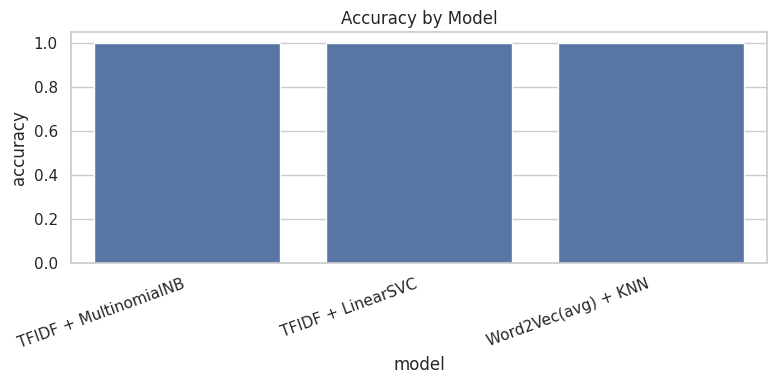

In [18]:
# Bar chart: Accuracy (all same here, but required)
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

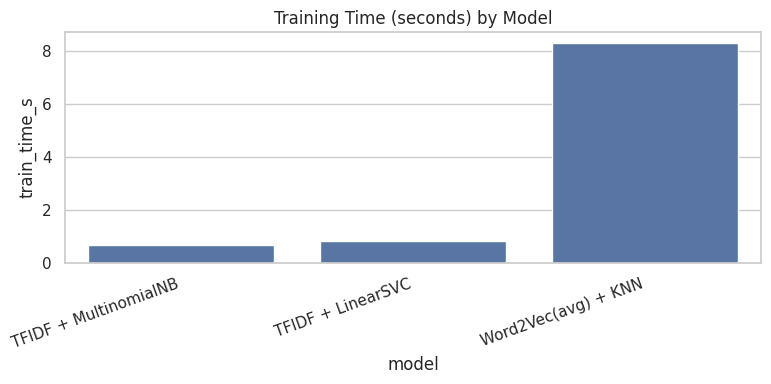

In [19]:
# Bar chart: Training time
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="train_time_s")
plt.title("Training Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

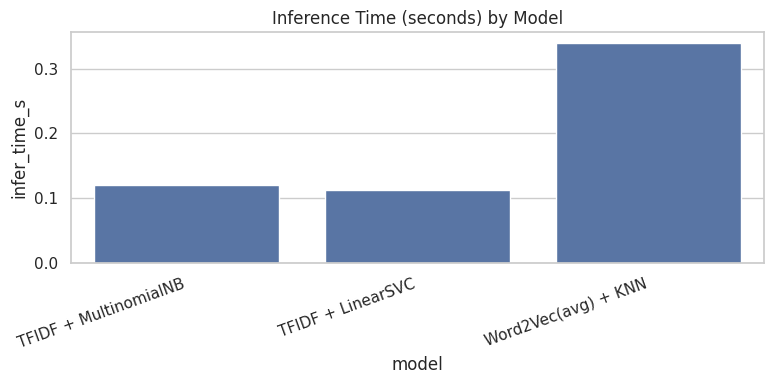

In [20]:
# Bar chart: Inference time
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="infer_time_s")
plt.title("Inference Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

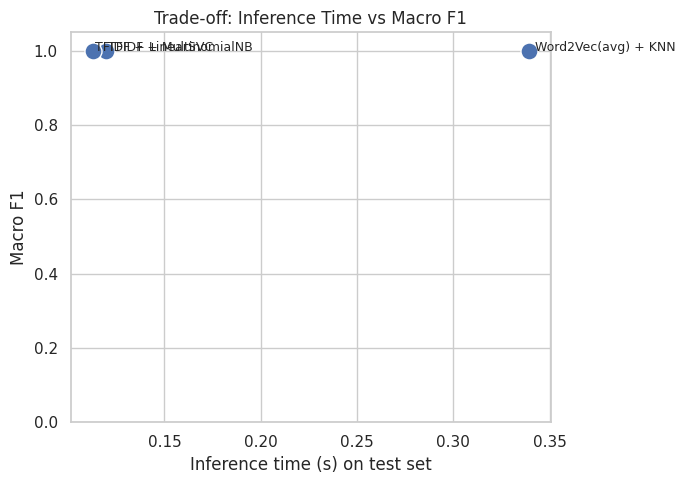

In [21]:
# Scatter: speed vs performance tradeoff (Inference time vs Macro F1)
plt.figure(figsize=(7,5))
ax = sns.scatterplot(data=res_df, x="infer_time_s", y="macro_f1", s=150)

for _, r in res_df.iterrows():
    ax.text(r["infer_time_s"]*1.01, r["macro_f1"], r["model"], fontsize=9)

plt.title("Trade-off: Inference Time vs Macro F1")
plt.xlabel("Inference time (s) on test set")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

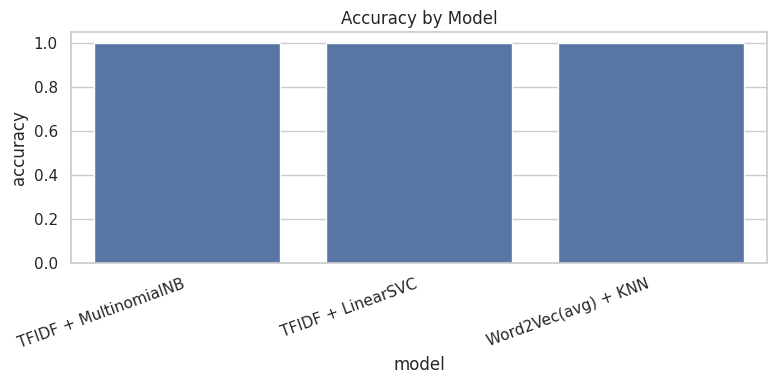

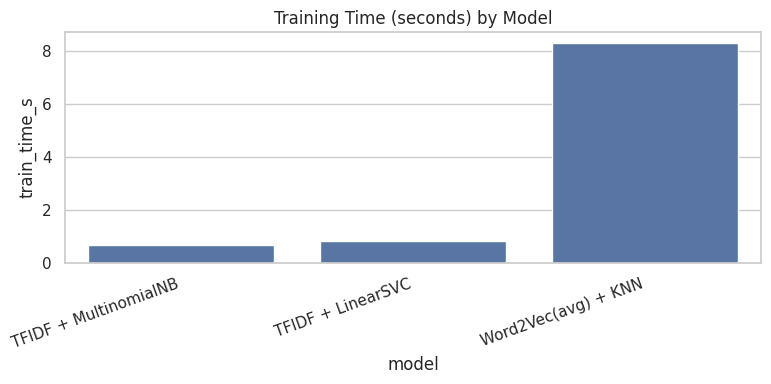

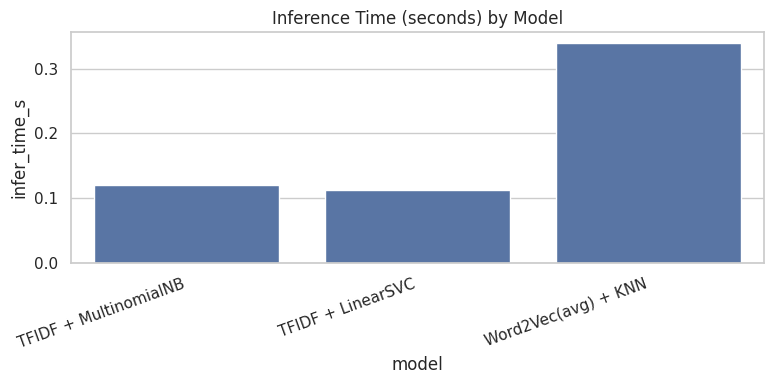

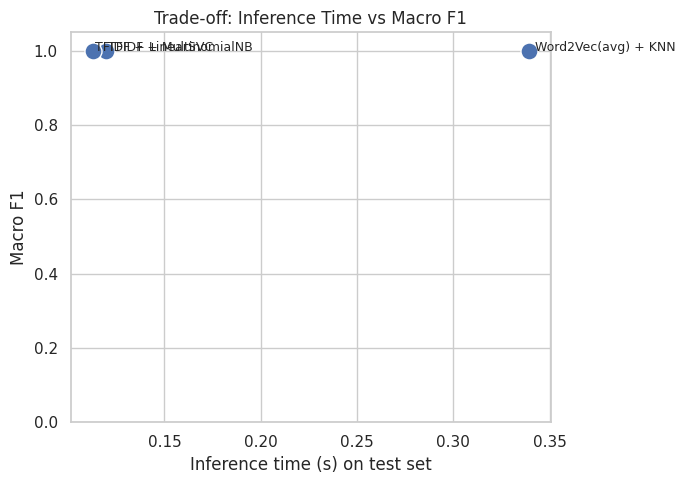

Saved files: ['accuracy_by_model.png', 'infer_time_by_model.png', 'train_time_by_model.png', 'tradeoff_scatter.png']


In [22]:
import os
os.makedirs("figs", exist_ok=True)

res_df = pd.DataFrame(results)

# 1) Accuracy bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/accuracy_by_model.png", dpi=200)
plt.show()

# 2) Training time bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="train_time_s")
plt.title("Training Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/train_time_by_model.png", dpi=200)
plt.show()

# 3) Inference time bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="infer_time_s")
plt.title("Inference Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/infer_time_by_model.png", dpi=200)
plt.show()

# 4) Scatter trade-off
plt.figure(figsize=(7,5))
ax = sns.scatterplot(data=res_df, x="infer_time_s", y="macro_f1", s=150)

for _, r in res_df.iterrows():
    ax.text(r["infer_time_s"]*1.01, r["macro_f1"], r["model"], fontsize=9)

plt.title("Trade-off: Inference Time vs Macro F1")
plt.xlabel("Inference time (s) on test set")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("figs/tradeoff_scatter.png", dpi=200)
plt.show()

print("Saved files:", os.listdir("figs"))

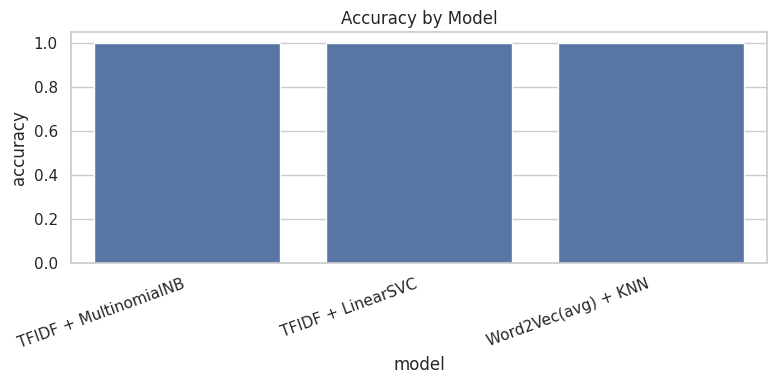

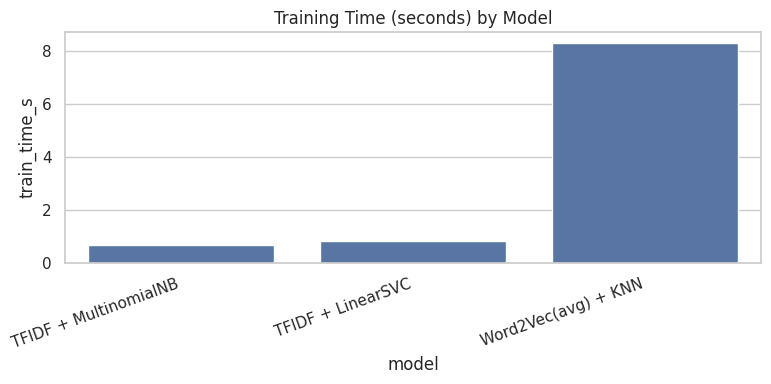

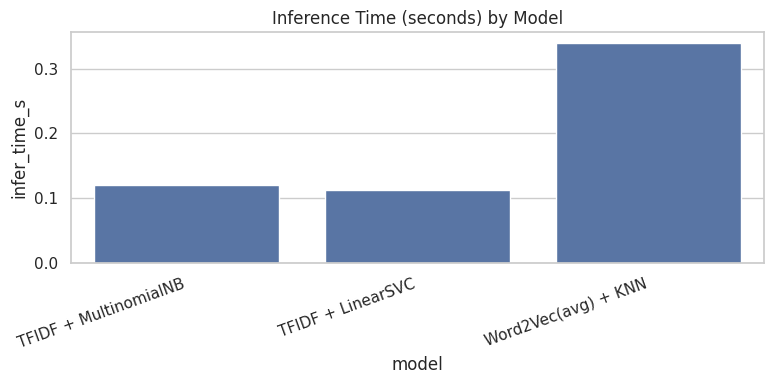

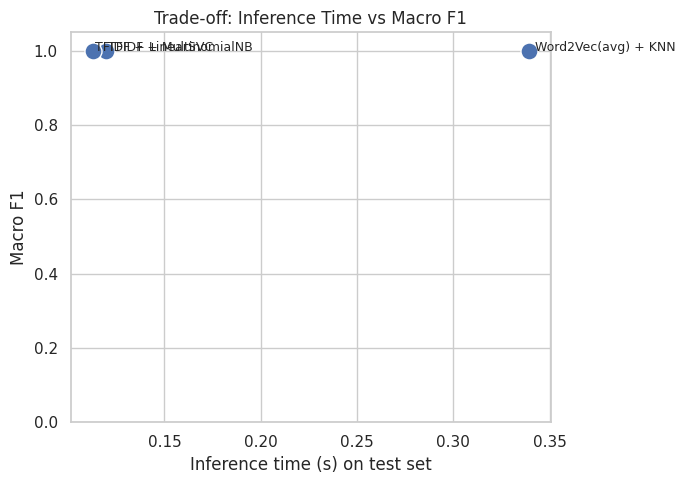

Saved files: ['accuracy_by_model.png', 'infer_time_by_model.png', 'train_time_by_model.png', 'tradeoff_scatter.png']


In [23]:
import os
os.makedirs("figs", exist_ok=True)

res_df = pd.DataFrame(results)

# 1) Accuracy bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="accuracy")
plt.ylim(0, 1.05)
plt.title("Accuracy by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/accuracy_by_model.png", dpi=200)
plt.show()

# 2) Training time bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="train_time_s")
plt.title("Training Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/train_time_by_model.png", dpi=200)
plt.show()

# 3) Inference time bar
plt.figure(figsize=(8,4))
sns.barplot(data=res_df, x="model", y="infer_time_s")
plt.title("Inference Time (seconds) by Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figs/infer_time_by_model.png", dpi=200)
plt.show()

# 4) Scatter trade-off
plt.figure(figsize=(7,5))
ax = sns.scatterplot(data=res_df, x="infer_time_s", y="macro_f1", s=150)

for _, r in res_df.iterrows():
    ax.text(r["infer_time_s"]*1.01, r["macro_f1"], r["model"], fontsize=9)

plt.title("Trade-off: Inference Time vs Macro F1")
plt.xlabel("Inference time (s) on test set")
plt.ylabel("Macro F1")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("figs/tradeoff_scatter.png", dpi=200)
plt.show()

print("Saved files:", os.listdir("figs"))